In [1]:
# Loading data
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Scaling
X_train = X_train/255
X_test = X_test/255

In [3]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
# Reshaping X_train
X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [10]:
# Defining our autoencoder model
from keras.models import Model
from keras import layers, losses

class Autoencoder(Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.encoder = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(latent_dim, activation='relu')
    ])

    self.decoder = tf.keras.Sequential([
        layers.Dense(28*28, activation='sigmoid'),
        layers.Reshape((28, 28, 1))
    ])

  def call(self, input_data):
    encoded = self.encoder(input_data)
    decoded = self.decoder(encoded)
    return decoded

In [11]:
# Training the model
autoencoder = Autoencoder(latent_dim=64)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())
autoencoder.fit(X_train, X_train, epochs=10, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0946 - val_loss: 0.0318
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0287 - val_loss: 0.0204
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0192 - val_loss: 0.0148
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0142 - val_loss: 0.0113
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0110 - val_loss: 0.0091
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0089 - val_loss: 0.0075
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0075 - val_loss: 0.0065
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0065 - val_loss: 0.0058
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0059 - val_loss: 0.0054
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0050


### Visualizing original and reconstructed data

In [12]:
encoded_imgs = autoencoder.encoder(X_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

Text(0.5, 1.0, 'reconstructed')

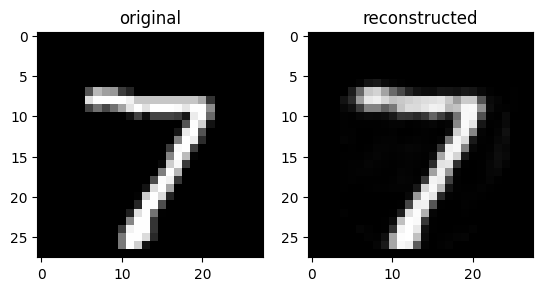

In [15]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title('original')

plt.subplot(1, 2, 2)
plt.imshow(decoded_imgs[0].reshape(28, 28), cmap='gray')
plt.title('reconstructed')

Text(0.5, 1.0, 'reconstructed')

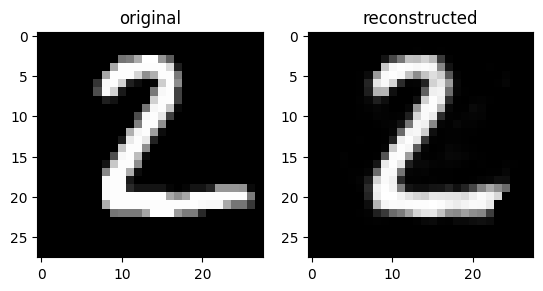

In [16]:
plt.subplot(1, 2, 1)
plt.imshow(X_test[1].reshape(28, 28), cmap='gray')
plt.title('original')

plt.subplot(1, 2, 2)
plt.imshow(decoded_imgs[1].reshape(28, 28), cmap='gray')
plt.title('reconstructed')

Text(0.5, 1.0, 'reconstructed')

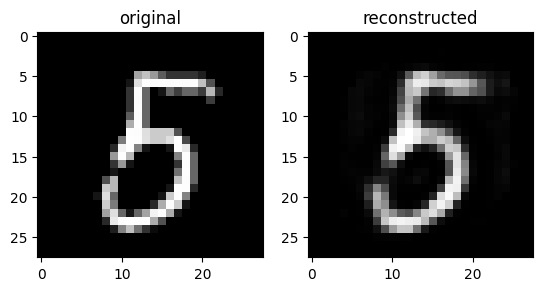

In [17]:
plt.subplot(1, 2, 1)
plt.imshow(X_test[45].reshape(28, 28), cmap='gray')
plt.title('original')

plt.subplot(1, 2, 2)
plt.imshow(decoded_imgs[45].reshape(28, 28), cmap='gray')
plt.title('reconstructed')